# Model Evaluation & Visualizations
Notebook này chuyên dùng để đánh giá, trực quan hóa và so sánh hiệu suất của 2 model: **Logistic Regression** và **Random Forest**.

In [1]:
import sys
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from joblib import load

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, 
    roc_auc_score, confusion_matrix, RocCurveDisplay, PrecisionRecallDisplay
)

# Thiết lập thư mục gốc
PROJECT_ROOT = Path.cwd().parent
sys.path.insert(0, str(PROJECT_ROOT))

SPLITS_DIR = PROJECT_ROOT / 'data' / 'processed' / 'splits'
MODELS_DIR = PROJECT_ROOT / 'models'

TARGET = 'Diabetes_binary'
NUMERIC_COLS = ['BMI', 'PhysHlth', 'MentHlth']

sns.set_theme(style='whitegrid')

## 1. Nạp Dữ Liệu Test & Artifacts (Tiền xử lý)
Mô phỏng lại đúng quá trình đưa data vào pipeline như ở thực tế (Production).

In [2]:
print('[*] Loading raw test data...')
test_lr = pd.read_csv(SPLITS_DIR / 'test_lr.csv')
test_rf = pd.read_csv(SPLITS_DIR / 'test_rf.csv')

X_test_lr, y_test_lr = test_lr.drop(columns=[TARGET]), test_lr[TARGET].astype('int64')
X_test_rf, y_test_rf = test_rf.drop(columns=[TARGET]), test_rf[TARGET].astype('int64')

print('[*] Loading preprocessors...')
scaler = load(MODELS_DIR / 'lr_scaler.joblib')
rf_arts = load(MODELS_DIR / 'rf_preproc.joblib')
imputer = rf_arts['imputer']
bounds = rf_arts['winsor_bounds']

# Áp dụng Preprocessing cho LR
X_test_lr_scaled = X_test_lr.copy()
X_test_lr_scaled[NUMERIC_COLS] = scaler.transform(X_test_lr[NUMERIC_COLS])

# Áp dụng Preprocessing cho RF
X_test_rf_w = X_test_rf.copy()
X_test_rf_w[NUMERIC_COLS] = imputer.transform(X_test_rf[NUMERIC_COLS])
for col, (lo, hi) in bounds.items():
    if col in X_test_rf_w.columns and not (np.isnan(lo) or np.isnan(hi)):
        X_test_rf_w[col] = X_test_rf_w[col].clip(lower=lo, upper=hi)

print('Data processing ready!')

[*] Loading raw test data...
[*] Loading preprocessors...
Data processing ready!


## 2. Load Models & Đánh giá Metrics cơ bản

In [3]:
print('[*] Loading trained models...')
lr_model = load(MODELS_DIR / 'logistic_regression.joblib')
rf_model = load(MODELS_DIR / 'random_forest.joblib')

def get_metrics(name, model, X, y):
    y_pred = model.predict(X)
    y_prob = model.predict_proba(X)[:, 1] if hasattr(model, 'predict_proba') else model.decision_function(X)
    return {
        'Model': name,
        'Accuracy': accuracy_score(y, y_pred),
        'Precision': precision_score(y, y_pred),
        'Recall': recall_score(y, y_pred),
        'F1 Score': f1_score(y, y_pred),
        'ROC AUC': roc_auc_score(y, y_prob)
    }, y_pred, y_prob

lr_metrics, lr_pred, lr_prob = get_metrics('Logistic Regression', lr_model, X_test_lr_scaled, y_test_lr)
rf_metrics, rf_pred, rf_prob = get_metrics('Random Forest', rf_model, X_test_rf_w, y_test_rf)

metrics_df = pd.DataFrame([lr_metrics, rf_metrics]).set_index('Model')
display(metrics_df)

[*] Loading trained models...


,Accuracy,Precision,Recall,F1 Score,ROC AUC
Model,,,,,
Logistic Regression,0.726250,0.306382,0.763333,0.437259,0.815804
Random Forest,0.856749,0.458559,0.155750,0.232524,0.794987


## 3. Biểu đồ so sánh Metrics

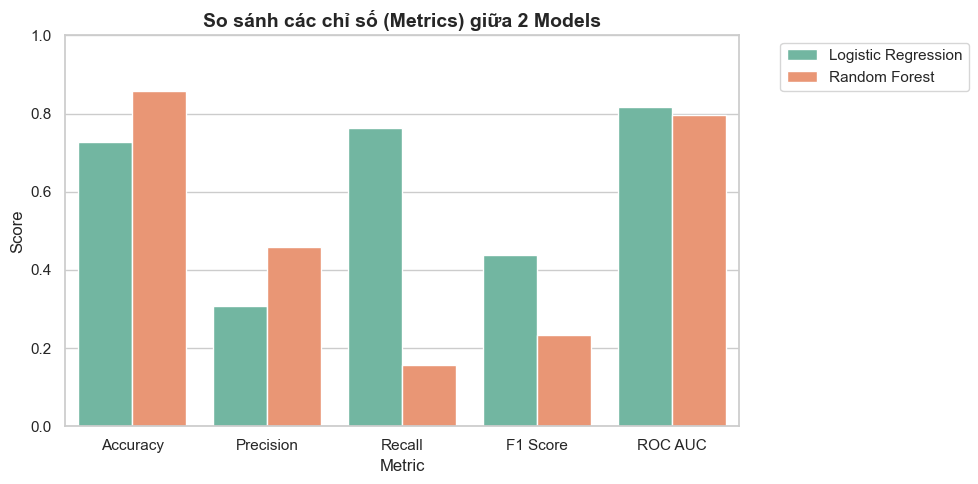

In [4]:
plot_df = metrics_df.reset_index().melt(id_vars='Model', var_name='Metric', value_name='Score')
plt.figure(figsize=(10, 5))
sns.barplot(data=plot_df, x='Metric', y='Score', hue='Model', palette='Set2')
plt.ylim(0, 1)
plt.title('So sánh các chỉ số (Metrics) giữa 2 Models', fontsize=14, fontweight='bold')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

## 4. Confusion Matrix (Ma trận nhầm lẫn)

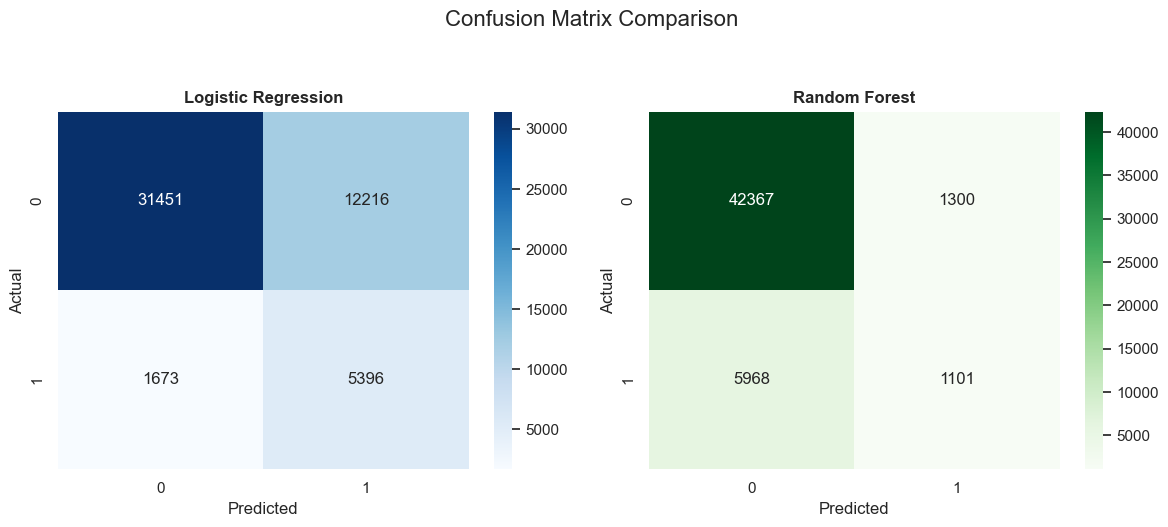

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

sns.heatmap(confusion_matrix(y_test_lr, lr_pred), annot=True, fmt='d', cmap='Blues', ax=axes[0])
axes[0].set_title('Logistic Regression', fontweight='bold')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('Actual')

sns.heatmap(confusion_matrix(y_test_rf, rf_pred), annot=True, fmt='d', cmap='Greens', ax=axes[1])
axes[1].set_title('Random Forest', fontweight='bold')
axes[1].set_xlabel('Predicted')
axes[1].set_ylabel('Actual')

plt.suptitle('Confusion Matrix Comparison', fontsize=16, y=1.05)
plt.tight_layout()
plt.show()

## 5. ROC Curve & Precision-Recall Curve
Cho thấy khả năng phân tách giữa lớp Bệnh và Không bệnh của Models.

c:\Users\ASUS\miniconda3\envs\data_science\Lib\site-packages\sklearn\utils\_plotting.py:176: FutureWarning: `**kwargs` is deprecated and will be removed in 1.9. Pass all matplotlib arguments to `curve_kwargs` as a dictionary instead.
  warnings.warn(
c:\Users\ASUS\miniconda3\envs\data_science\Lib\site-packages\sklearn\utils\_plotting.py:176: FutureWarning: `**kwargs` is deprecated and will be removed in 1.9. Pass all matplotlib arguments to `curve_kwargs` as a dictionary instead.
  warnings.warn(


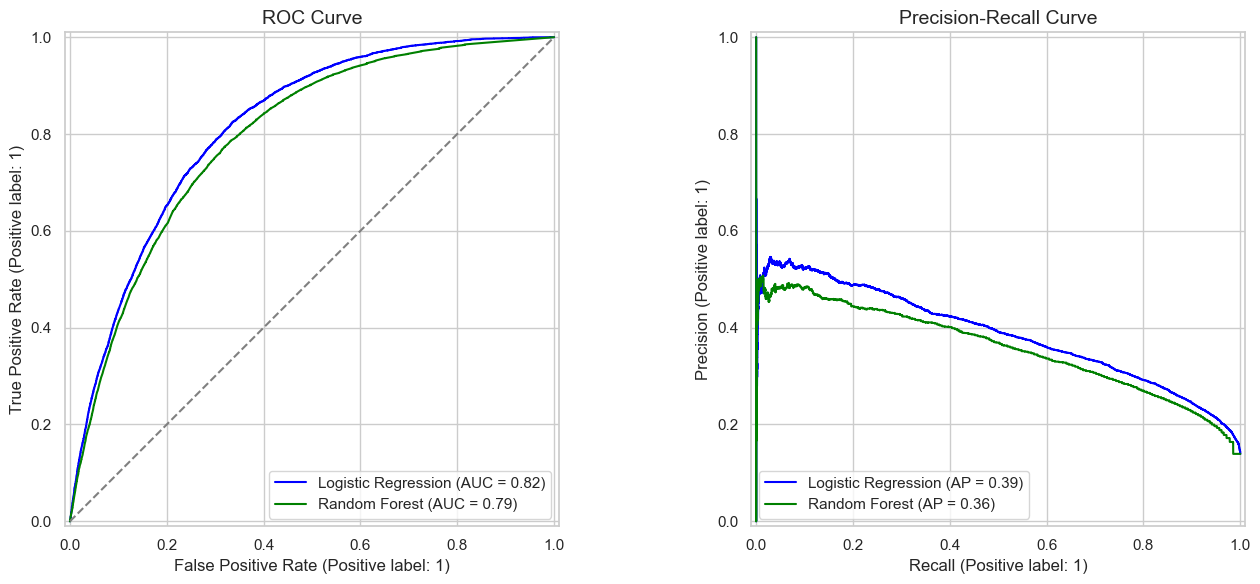

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# ROC Curve
RocCurveDisplay.from_predictions(y_test_lr, lr_prob, ax=axes[0], name='Logistic Regression', color='blue')
RocCurveDisplay.from_predictions(y_test_rf, rf_prob, ax=axes[0], name='Random Forest', color='green')
axes[0].plot([0, 1], [0, 1], color='gray', linestyle='--')
axes[0].set_title('ROC Curve', fontsize=14)

# PR Curve
PrecisionRecallDisplay.from_predictions(y_test_lr, lr_prob, ax=axes[1], name='Logistic Regression', color='blue')
PrecisionRecallDisplay.from_predictions(y_test_rf, rf_prob, ax=axes[1], name='Random Forest', color='green')
axes[1].set_title('Precision-Recall Curve', fontsize=14)

plt.tight_layout()
plt.show()

## 6. Mức độ quan trọng của đặc trưng (Feature Importances - Random Forest)

C:\Users\ASUS\AppData\Local\Temp\ipykernel_14344\4204463098.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=rf_importance.head(15).values, y=rf_importance.head(15).index, palette='viridis')


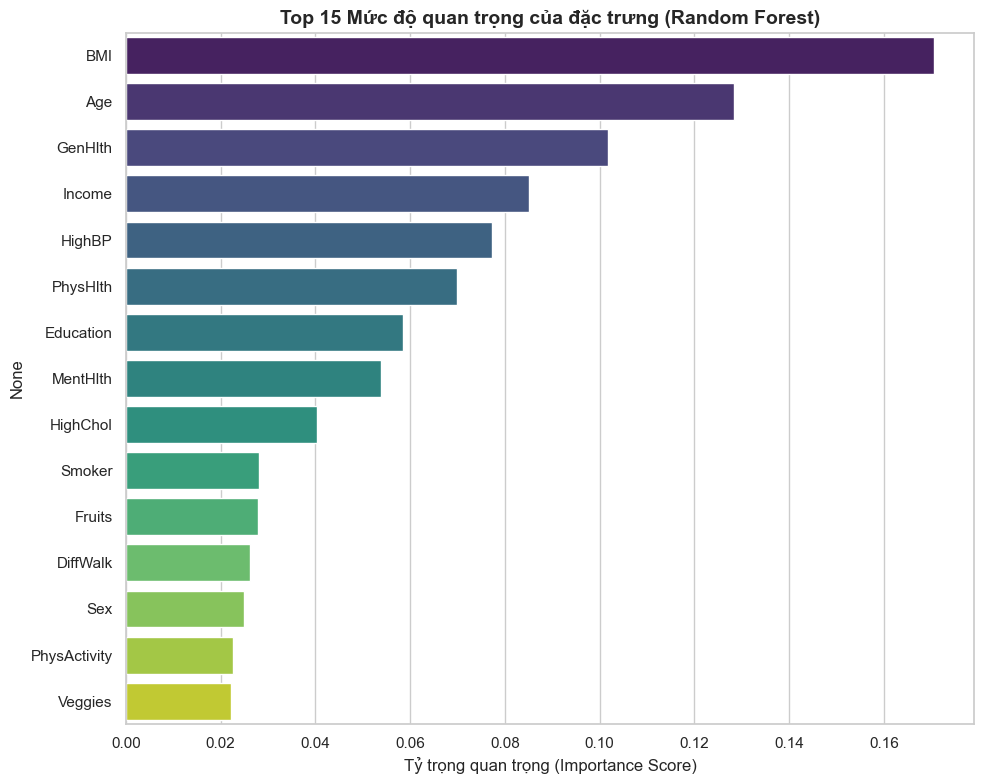

In [7]:
rf_importance = pd.Series(rf_model.feature_importances_, index=X_test_rf_w.columns).sort_values(ascending=False)
plt.figure(figsize=(10, 8))
sns.barplot(x=rf_importance.head(15).values, y=rf_importance.head(15).index, palette='viridis')
plt.title('Top 15 Mức độ quan trọng của đặc trưng (Random Forest)', fontsize=14, fontweight='bold')
plt.xlabel('Tỷ trọng quan trọng (Importance Score)')
plt.tight_layout()
plt.show()